# Trabalho de Séries Temporais: Modelagem Comparativa com Variáveis Externas
## Grupo 4 - Modelo de Especialização: **MLP Regressor (Rede Neural Artificial)**
**Base de Dados:** Bike Sales (`Sales.csv`)

---

### 🎯 Objetivos e Diretrizes do Trabalho
1. **Apresentação e Documentação da Base**: Mapear a base, características temporais, variáveis externas e decisões de limpeza e agregação.
2. **Tratamento e Preparação dos Dados**: Conversão de datas, agregação diária contínua (`asfreq('D')`), divisão temporal entre treino e teste.
3. **Análise Visual e Decomposição STL**: Avaliar tendência, sazonalidade e resíduos, calculando quantitativamente a **Força da Sazonalidade ($F_s$)** e da **Tendência ($F_t$)**.
4. **Testes Estatísticos de Estacionariedade**: Execução formal dos testes **ADF** e **KPSS**, análise de hipóteses e justificativa de diferenciação.
5. **Diferenciação e Análise de ACF & PACF**: Identificação de padrões autorregressivos e de médias móveis através dos correlogramas.
6. **Construção dos Modelos Base (Baselines)**: Implementação e otimização de Média Móvel, Média Acumulada, EMA, Seasonal Naive e Delta.
7. **Modelagem Clássica e Suavização Exponencial (Holt-Winters)**: Comparação entre Suavização Exponencial Simples (SES) e Holt-Winters Aditivo com métricas AIC e BIC.
8. **Seleção de Parâmetros e Modelo SARIMA/SARIMAX**: Busca em grade (*Grid Search*) por critério BIC/AIC e diagnóstico do modelo.
9. **Feature Engineering e Prevenção de Vazamento (*Data Leakage*)**: Criação de lags do alvo, defasagens de variáveis externas e componentes cíclicos de calendário.
10. **Otimização de Hiperparâmetros de Machine Learning**: Ajuste fino do Random Forest e do modelo de especialização (**MLP Regressor**).
11. **Validação Walk-Forward (*Out-of-Sample*)**: Protocolo dinâmico de previsão comparando simultaneamente os 4 modelos nos mesmos dados.
12. **Avaliação Comparativa por MAE e Métricas de Erro**: Tabela e ranking consolidado de desempenho.
13. **Diagnóstico dos Resíduos e Teste de Ljung-Box**: Avaliação de ruído branco e ausência de autocorrelação residual.
14. **Importância das Features**: Interpretação preditiva via *Permutation Importance*, MDI e coeficientes exógenos.
15. **Estudo Aprofundado do Modelo de Especialização (MLP Regressor)**: Exposição teórica, formulação matemática e análise arquitetural da Rede Neural.

## 1. Configuração do Ambiente e Importação de Bibliotecas

In [1]:
import os
import time
import warnings
import itertools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos Estatísticos, Testes e Decomposição
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# Modelos de Machine Learning e Redes Neurais
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

# Configurações estéticas de gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Apresentação e Documentação da Base de Dados

### 📋 Dicionário de Dados e Metadados
- **Contexto da Análise**: Análise temporal e preditiva de vendas operacionais em rede varejista internacional de bicicletas, acessórios e vestuário esportivo (*Bike Sales Dataset*).
- **Variável Temporal Utilizada**: Coluna `Date` (registros de transações).
- **Variável Analisada (Alvo)**: `Revenue` (Faturamento total diário consolidado em USD $).
- **Variáveis Externas Relevantes**:
  - `Order_Quantity`: Quantidade total de unidades vendidas no dia.
  - `Cost`: Custo total diário dos produtos vendidos.
  - `Profit`: Lucro líquido diário obtido.
  - `Unit_Price` / `Unit_Cost`: Preço médio e custo unitário médio praticados.
- **Frequência da Série**: Diária regular (`D`).
- **Período Total da Base**: 01/01/2011 a 31/07/2016 (~5,5 anos).

In [2]:
# Carregamento robusto da base de dados
file_candidates = [
    '../datasets/Sales.csv',
    'datasets/Sales.csv',
    'trabalhoseries_redeneural/datasets/Sales.csv'
]
csv_path = next((p for p in file_candidates if os.path.exists(p)), None)
if not csv_path:
    raise FileNotFoundError('Base Sales.csv não encontrada.')

df_raw = pd.read_csv(csv_path)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

print(f'Total de registros transacionais brutos: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas.')
print(f'Período bruto: {df_raw["Date"].min().strftime("%d/%m/%Y")} até {df_raw["Date"].max().strftime("%d/%m/%Y")}')
display(df_raw.head())
print('\nInformações gerais da base:')
df_raw.info()
print('\nValores ausentes por coluna:')
print(df_raw.isna().sum())

Total de registros transacionais brutos: 113,036 linhas x 18 colunas.
Período bruto: 01/01/2011 até 31/07/2016


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418



Informações gerais da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              113036 non-null  datetime64[ns]
 1   Day               113036 non-null  int64         
 2   Month             113036 non-null  object        
 3   Year              113036 non-null  int64         
 4   Customer_Age      113036 non-null  int64         
 5   Age_Group         113036 non-null  object        
 6   Customer_Gender   113036 non-null  object        
 7   Country           113036 non-null  object        
 8   State             113036 non-null  object        
 9   Product_Category  113036 non-null  object        
 10  Sub_Category      113036 non-null  object        
 11  Product           113036 non-null  object        
 12  Order_Quantity    113036 non-null  int64         
 13  Unit_Cost         113036 non-n

## 3. Tratamento e Preparação dos Dados

### 🧹 Agregação Diária e Decisão Metodológica de Recorte Temporal
- Os dados originais são transacionais (múltiplas linhas por dia). Agregamos a base na frequência diária (`D`) somando receitas, custos, quantidades e lucros.
- **Frequência Regular e Preenchimento**: Aplicamos `.asfreq('D', fill_value=0)` para garantir que nenhum dia seja omitido no índice cronológico.
- **Inspeção de Regime e Recorte**: Entre 2011 e meados de 2013, as operações eram esparsas e limitadas apenas a bicicletas. A partir de **Agosto de 2013**, houve a expansão estrutural do catálogo para acessórios e vestuário contínuo. Para evitar quebra estrutural severa, definimos o período de modelagem contínua de **01/08/2013 a 31/07/2016** (1.096 dias contínuos).

In [3]:
# Agregação Diária com frequência regular (asfreq D)
df_daily = df_raw.groupby('Date').agg({
    'Revenue': 'sum',
    'Order_Quantity': 'sum',
    'Cost': 'sum',
    'Profit': 'sum',
    'Unit_Price': 'mean',
    'Unit_Cost': 'mean'
}).asfreq('D', fill_value=0)

# Recorte temporal contínuo e homogêneo (01/08/2013 a 31/07/2016)
ts_data = df_daily[df_daily.index >= '2013-08-01'].copy()
series = ts_data[['Revenue']].copy()

print(f'Série Temporal Diária Consolidada: {len(series)} observações diárias contínuas.')
print(f'Intervalo: de {series.index.min().strftime("%d/%m/%Y")} a {series.index.max().strftime("%d/%m/%Y")}')
print(f'Valores nulos na série: {series.isna().sum().sum()}')
display(series.head())

Série Temporal Diária Consolidada: 1096 observações diárias contínuas.
Intervalo: de 01/08/2013 a 31/07/2016
Valores nulos na série: 0


,Revenue
Date,
2013-08-01,46095
2013-08-02,40768
2013-08-03,66315
2013-08-04,51932
2013-08-05,35271


## 4. Análise Visual da Série Temporal

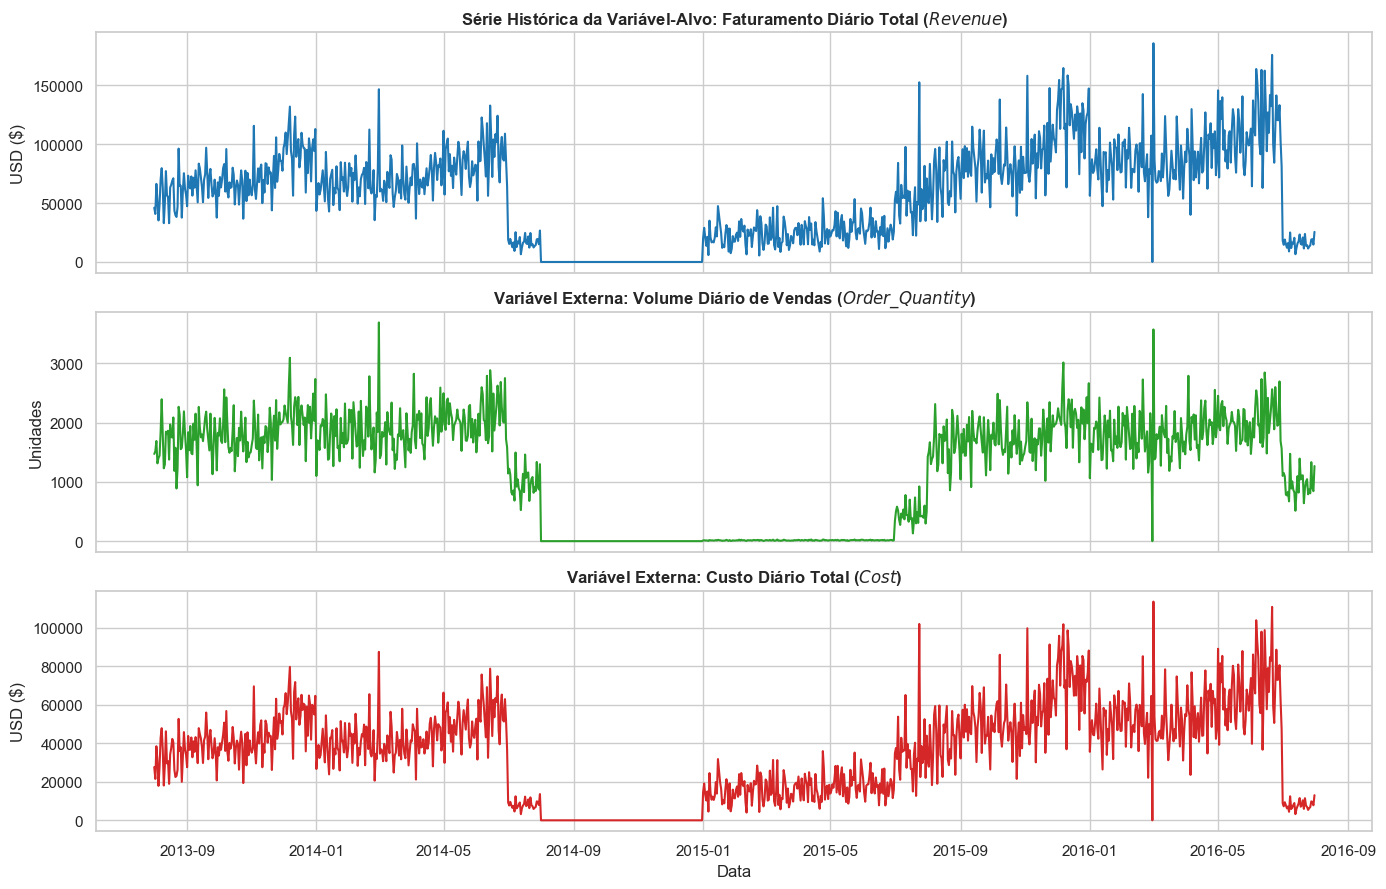

In [4]:
# Visualização da Série Histórica da Variável-Alvo e Exógenas
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(ts_data.index, ts_data['Revenue'], color='#1f77b4', lw=1.5)
axes[0].set_title('Série Histórica da Variável-Alvo: Faturamento Diário Total ($Revenue$)', fontweight='bold')
axes[0].set_ylabel('USD ($)')

axes[1].plot(ts_data.index, ts_data['Order_Quantity'], color='#2ca02c', lw=1.5)
axes[1].set_title('Variável Externa: Volume Diário de Vendas ($Order\\_Quantity$)', fontweight='bold')
axes[1].set_ylabel('Unidades')

axes[2].plot(ts_data.index, ts_data['Cost'], color='#d62728', lw=1.5)
axes[2].set_title('Variável Externa: Custo Diário Total ($Cost$)', fontweight='bold')
axes[2].set_ylabel('USD ($)')
axes[2].set_xlabel('Data')

plt.tight_layout()
plt.show()

## 5. Divisão Entre Treino e Teste

Para avaliação fora da amostra (*out-of-sample*), dividimos a série temporal de forma sequencial (80% treino inicial / 20% teste), preservando estritamente a ordem cronológica sem embaralhamento.

In [5]:
train_ratio = 0.80
split_idx = int(len(series) * train_ratio)

train = series.iloc[:split_idx]
test = series.iloc[split_idx:]
H = len(test)

print(f'Tamanho do conjunto de Treino: {len(train)} observações ({train.index.min().date()} a {train.index.max().date()})')
print(f'Tamanho do conjunto de Teste:  {len(test)} observações ({test.index.min().date()} a {test.index.max().date()})')
print(f'Horizonte de previsão H: {H} dias')

Tamanho do conjunto de Treino: 876 observações (2013-08-01 a 2015-12-24)
Tamanho do conjunto de Teste:  220 observações (2015-12-25 a 2016-07-31)
Horizonte de previsão H: 220 dias


## 6. Decomposição STL e Força dos Componentes

A decomposição **STL (Seasonal and Trend decomposition using Loess)** separa a série temporal $Y_t$ em três componentes aditivos:
$$Y_t = T_t + S_t + R_t$$
Onde:
- $T_t$: Tendência (*Trend*)
- $S_t$: Sazonalidade Semanal ($m=7$)
- $R_t$: Resíduo (*Residual*)

### Força da Sazonalidade e da Tendência
$$F_s = \max\left(0, 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(S_t + R_t)}\right), \quad F_t = \max\left(0, 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(T_t + R_t)}\right)$$

=== MÉTRICAS DE DECOMPOSIÇÃO TEMPORAL (STL NO TREINO) ===
Força da Sazonalidade (Fs): 0.0845 (8.45%)
Força da Tendência    (Ft): 0.8602 (86.02%)


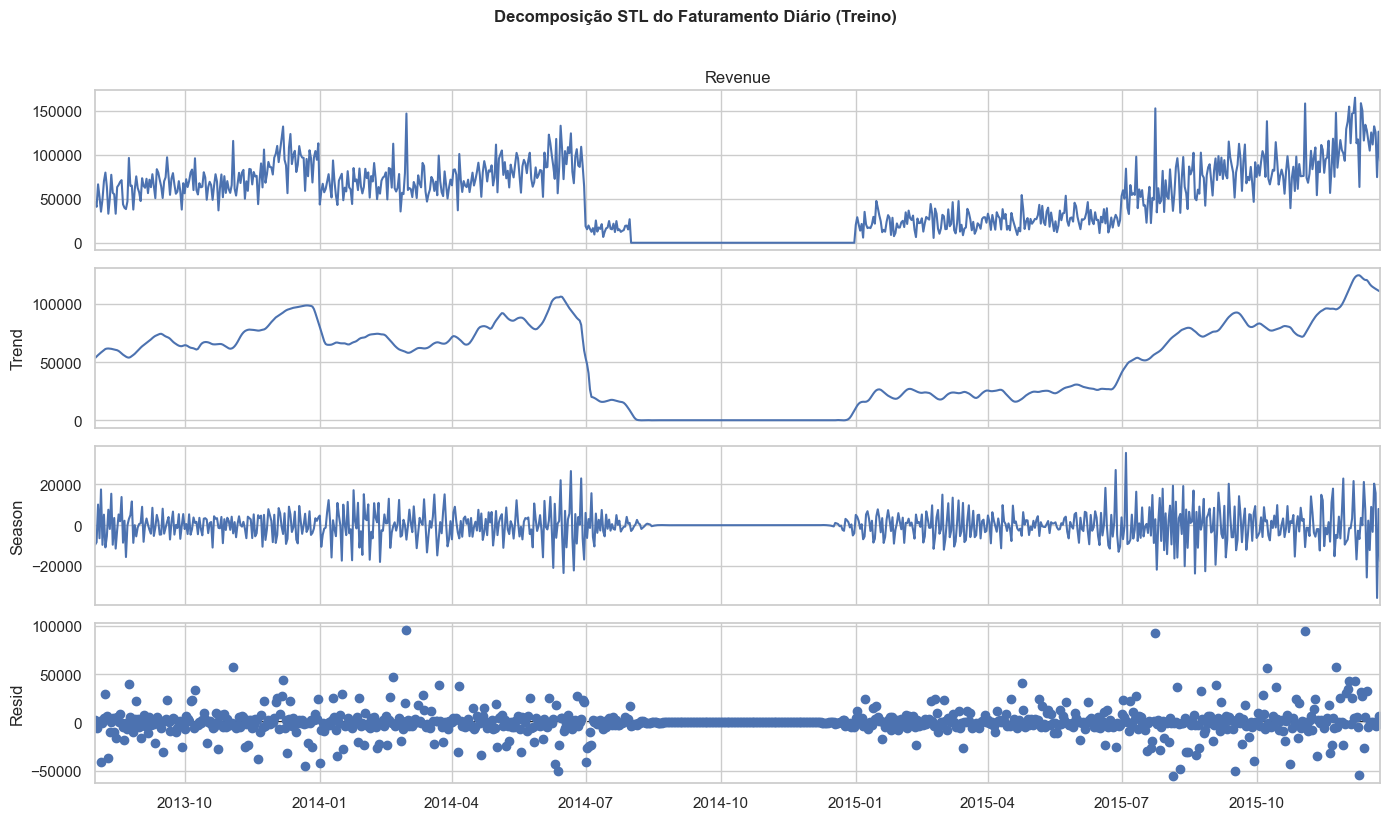

In [6]:
m = 7 # Período sazonal semanal
stl = STL(train['Revenue'], period=m, robust=True).fit()

# Cálculo das métricas quantitativas de Força de Tendência e Sazonalidade
var_resid = np.var(stl.resid)
var_seas_resid = np.var(stl.seasonal + stl.resid)
var_trend_resid = np.var(stl.trend + stl.resid)

fs = max(0.0, 1.0 - (var_resid / var_seas_resid))
ft = max(0.0, 1.0 - (var_resid / var_trend_resid))

print('=== MÉTRICAS DE DECOMPOSIÇÃO TEMPORAL (STL NO TREINO) ===')
print(f'Força da Sazonalidade (Fs): {fs:.4f} ({fs*100:.2f}%)')
print(f'Força da Tendência    (Ft): {ft:.4f} ({ft*100:.2f}%)')

fig = stl.plot()
fig.set_size_inches(14, 8)
plt.suptitle('Decomposição STL do Faturamento Diário (Treino)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Testes Formais de Estacionariedade

Para avaliar a estacionariedade da série de faturamento, aplicamos os testes estatísticos formais:
1. **ADF (*Augmented Dickey-Fuller*)**: $H_0$: A série possui raiz unitária (não é estacionária). Rejeitar $H_0$ ($p < 0.05$) indica estacionariedade.
2. **KPSS (*Kwiatkowski-Phillips-Schmidt-Shin*)**: $H_0$: A série é estacionária em torno de um nível determinístico. Rejeitar $H_0$ ($p < 0.05$) indica não estacionariedade.
3. **Função de Autocorrelação (ACF)** da série original.

--- TESTE ADF (Treino Original) ---
  ADF Statistic: -1.3245379578537377
  p-value: 0.6178727497964582
  Critical Values 1/5/10%: {'1%': np.float64(-3.4379061568421934), '5%': np.float64(-2.864875519613169), '10%': np.float64(-2.5685460785427594)}

--- TESTE KPSS (Treino Original) ---
  KPSS Statistic: 0.868928894159216
  p-value: 0.01
  Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\raissacasale-ieg\AppData\Local\Temp\ipykernel_26404\747456890.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(x.dropna())


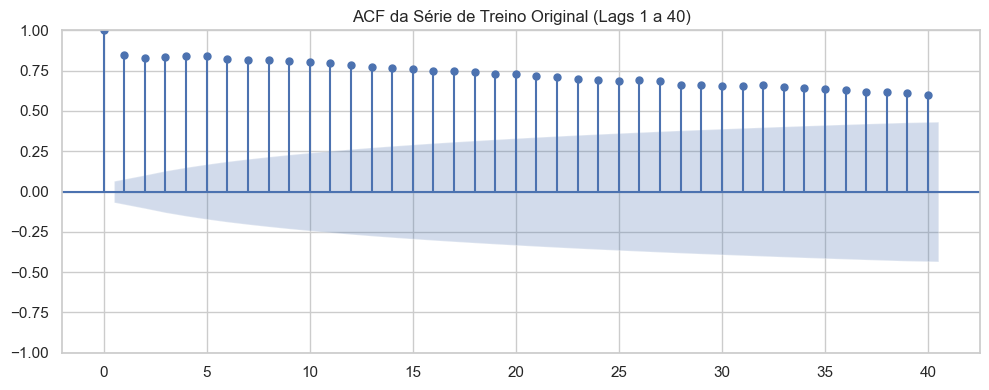

In [7]:
def test_adf(x, name='Série'):
    res = adfuller(x.dropna())
    results = {
        'ADF Statistic': res[0],
        'p-value': res[1],
        'Critical Values 1/5/10%': res[4]
    }
    print(f'--- TESTE ADF ({name}) ---')
    for k, v in results.items():
        print(f'  {k}: {v}')
    return res

def test_kpss(x, name='Série'):
    res = kpss(x.dropna())
    results = {
        'KPSS Statistic': res[0],
        'p-value': res[1],
        'Critical Values 10/5/2.5/1%': res[3]
    }
    print(f'--- TESTE KPSS ({name}) ---')
    for k, v in results.items():
        print(f'  {k}: {v}')
    return res

test_adf(train['Revenue'], name='Treino Original')
print()
test_kpss(train['Revenue'], name='Treino Original')

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(train['Revenue'], lags=40, ax=ax)
ax.set_title('ACF da Série de Treino Original (Lags 1 a 40)')
plt.tight_layout()
plt.show()

## 8. Diferenciação e Análise de ACF e PACF

Como a série original apresentou evidências de não estacionariedade no teste KPSS e decaimento persistente na ACF, aplicamos a primeira diferenciação:
$$\Delta Y_t = Y_t - Y_{t-1}$$
Em seguida, avaliamos os gráficos de ACF e PACF para determinar as ordens autorregressivas ($p$) e de médias móveis ($q$).

=== TESTES APÓS PRIMEIRA DIFERENCIAÇÃO (d=1) ===
--- TESTE ADF (Série Diferenciada (d=1)) ---
  ADF Statistic: -17.377473705262016
  p-value: 5.0957024657345836e-30
  Critical Values 1/5/10%: {'1%': np.float64(-3.4379061568421934), '5%': np.float64(-2.864875519613169), '10%': np.float64(-2.5685460785427594)}

--- TESTE KPSS (Série Diferenciada (d=1)) ---
  KPSS Statistic: 0.15404679994549855
  p-value: 0.1
  Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\raissacasale-ieg\AppData\Local\Temp\ipykernel_26404\747456890.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(x.dropna())


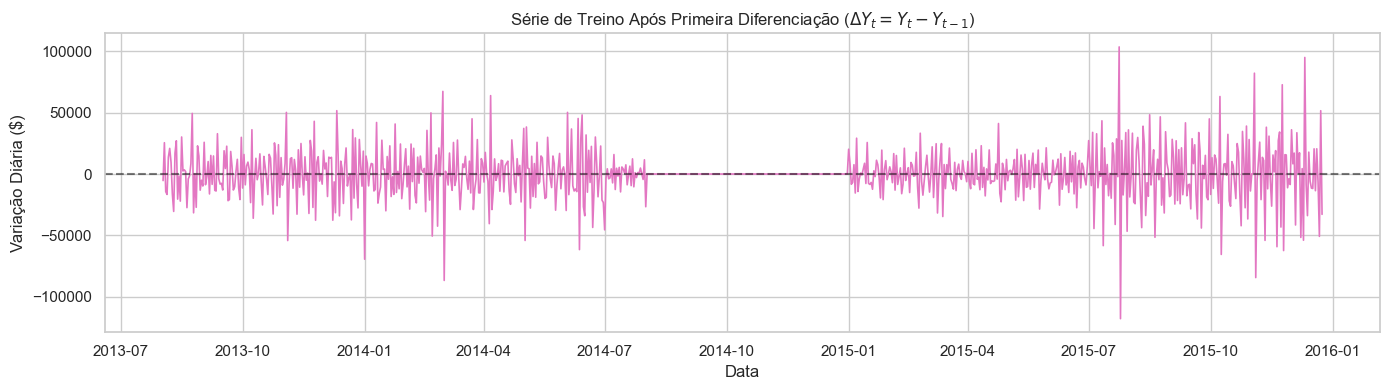

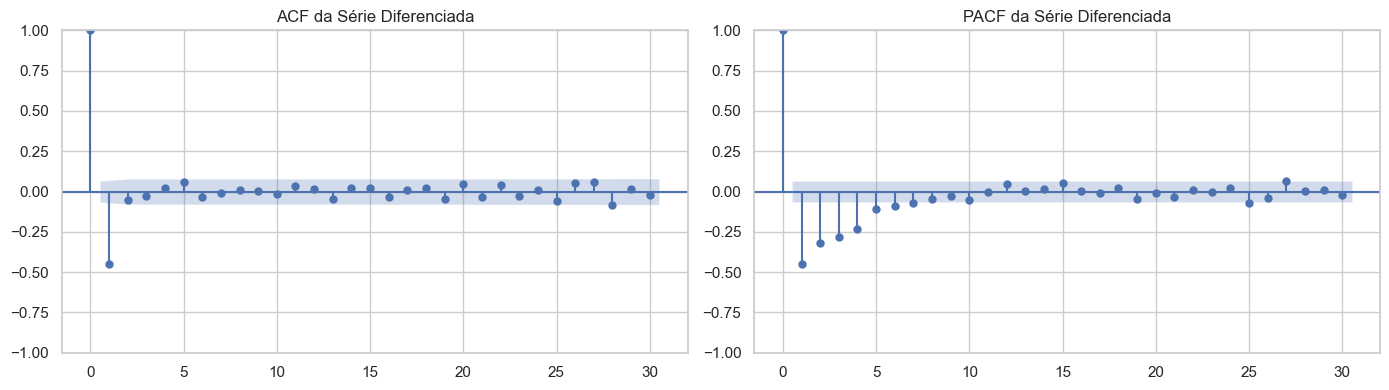

In [8]:
diff_train = train['Revenue'].diff(1).dropna()

print('=== TESTES APÓS PRIMEIRA DIFERENCIAÇÃO (d=1) ===')
test_adf(diff_train, name='Série Diferenciada (d=1)')
print()
test_kpss(diff_train, name='Série Diferenciada (d=1)')

# Plot da série diferenciada
plt.figure(figsize=(14, 4))
plt.plot(diff_train.index, diff_train.values, color='#e377c2', lw=1.2)
plt.title('Série de Treino Após Primeira Diferenciação ($\Delta Y_t = Y_t - Y_{t-1}$)')
plt.xlabel('Data')
plt.ylabel('Variação Diária ($)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Correlogramas ACF e PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_train, lags=30, ax=axes[0], title='ACF da Série Diferenciada')
plot_pacf(diff_train, lags=30, ax=axes[1], title='PACF da Série Diferenciada')
plt.tight_layout()
plt.show()

## 9. Construção dos Modelos Base (*Baselines*)

Implementamos os modelos base com ajuste de hiperparâmetros no treino e avaliação no teste:
1. **Média Móvel (Rolling Mean)**: Otimização da janela $k \in \{1, 2, 3, 5, 7, 14, 28\}$.
2. **Média Acumulada (Expanding Mean)**: $\hat{Y}_t = \frac{1}{t-1} \sum_{i=1}^{t-1} Y_i$.
3. **EMA (Exponential Moving Average)**: Otimização do coeficiente de suavização $\alpha \in [0.1, 0.9]$.
4. **Seasonal Naive**: Otimização do lag sazonal $s \in \{1, 2, 3, 7, 14, 28\}$.
5. **Delta**: Otimização da janela de tendência $j \in \{1, 2, 3, 7, 14, 28\}$.

In [9]:
y = series['Revenue']
y_train = train['Revenue']
y_test = test['Revenue']

sumario = {}

# 1. Média Móvel
ks = [1, 2, 3, 5, 7, 14, 28]
k_max = max(ks)
mm_detalhado = {}
resultado_mm = []

for k in ks:
    pred_full = y.rolling(window=k).mean().shift(1)
    mm_detalhado[f'mm_{k}'] = pred_full
    mae_train = mean_absolute_error(y_train.iloc[k_max:], pred_full.loc[y_train.index].iloc[k_max:])
    mae_test = mean_absolute_error(y_test, pred_full.loc[y_test.index])
    resultado_mm.append({'k': k, 'MAE_train': mae_train, 'MAE_test': mae_test})

df_res_mm = pd.DataFrame(resultado_mm)
best_k = int(df_res_mm.loc[df_res_mm['MAE_train'].idxmin(), 'k'])
sumario['Média Móvel'] = {
    'Parâmetro': f'k={best_k}',
    'MAE_train': df_res_mm.loc[df_res_mm['MAE_train'].idxmin(), 'MAE_train'],
    'MAE_test': df_res_mm.loc[df_res_mm['MAE_train'].idxmin(), 'MAE_test']
}

# 2. Média Acumulada
pred_exp = y.expanding().mean().shift(1)
sumario['Média Acumulada'] = {
    'Parâmetro': '-',
    'MAE_train': mean_absolute_error(y_train.iloc[1:], pred_exp.loc[y_train.index].iloc[1:]),
    'MAE_test': mean_absolute_error(y_test, pred_exp.loc[y_test.index])
}

# 3. EMA
alphas = np.round(np.arange(0.1, 1.0, 0.1), 2)
resultado_ema = []
for alpha in alphas:
    pred_ema = y.ewm(alpha=alpha, adjust=False).mean().shift(1)
    mae_train = mean_absolute_error(y_train.iloc[1:], pred_ema.loc[y_train.index].iloc[1:])
    mae_test = mean_absolute_error(y_test, pred_ema.loc[y_test.index])
    resultado_ema.append({'Alpha': alpha, 'MAE_train': mae_train, 'MAE_test': mae_test})

df_res_ema = pd.DataFrame(resultado_ema)
best_alpha = df_res_ema.loc[df_res_ema['MAE_train'].idxmin(), 'Alpha']
sumario['EMA'] = {
    'Parâmetro': f'alpha={best_alpha}',
    'MAE_train': df_res_ema.loc[df_res_ema['MAE_train'].idxmin(), 'MAE_train'],
    'MAE_test': df_res_ema.loc[df_res_ema['MAE_train'].idxmin(), 'MAE_test']
}

# 4. Seasonal Naive
ss = [1, 2, 3, 7, 14, 28]
s_max = max(ss)
resultado_sn = []
for s in ss:
    pred_sn = y.shift(s)
    mae_train = mean_absolute_error(y_train.iloc[s_max:], pred_sn.loc[y_train.index].iloc[s_max:])
    mae_test = mean_absolute_error(y_test, pred_sn.loc[y_test.index])
    resultado_sn.append({'Sazonalidade': s, 'MAE_train': mae_train, 'MAE_test': mae_test})

df_res_sn = pd.DataFrame(resultado_sn)
best_s = int(df_res_sn.loc[df_res_sn['MAE_train'].idxmin(), 'Sazonalidade'])
sumario['Seasonal Naive'] = {
    'Parâmetro': f's={best_s}',
    'MAE_train': df_res_sn.loc[df_res_sn['MAE_train'].idxmin(), 'MAE_train'],
    'MAE_test': df_res_sn.loc[df_res_sn['MAE_train'].idxmin(), 'MAE_test']
}

# 5. Delta
janelas = [1, 2, 3, 7, 14, 28]
j_max = max(janelas)
resultado_delta = []
for j in janelas:
    pred_delta = y.shift(1) + (y.shift(1) - y.shift(1 + j)) / j
    mae_train = mean_absolute_error(y_train.iloc[1+j_max:], pred_delta.loc[y_train.index].iloc[1+j_max:])
    mae_test = mean_absolute_error(y_test, pred_delta.loc[y_test.index])
    resultado_delta.append({'Janela': j, 'MAE_train': mae_train, 'MAE_test': mae_test})

df_res_delta = pd.DataFrame(resultado_delta)
best_j = int(df_res_delta.loc[df_res_delta['MAE_train'].idxmin(), 'Janela'])
sumario['Delta'] = {
    'Parâmetro': f'j={best_j}',
    'MAE_train': df_res_delta.loc[df_res_delta['MAE_train'].idxmin(), 'MAE_train'],
    'MAE_test': df_res_delta.loc[df_res_delta['MAE_train'].idxmin(), 'MAE_test']
}

df_baselines = pd.DataFrame.from_dict(sumario, orient='index').reset_index().rename(columns={'index': 'Modelo'})
print('=== DESEMPENHO DOS MODELOS BASE (BASELINES) ===')
display(df_baselines.sort_values(by='MAE_test'))

=== DESEMPENHO DOS MODELOS BASE (BASELINES) ===


,Modelo,Parâmetro,MAE_train,MAE_test
2,EMA,alpha=0.2,10781.80,18929.15
0,Média Móvel,k=7,10742.42,18976.54
3,Seasonal Naive,s=1,13801.12,22903.84
4,Delta,j=28,14110.02,23470.79
1,Média Acumulada,-,29748.99,42205.10


## 10. Suavização Exponencial e Modelo Holt-Winters

Conforme a pipeline metodológica de referência, comparamos os métodos de Suavização Exponencial Simples (**SES**) e **Holt-Winters Aditivo** com período sazonal $m=7$, avaliando **AIC**, **BIC** e o **MAE** no conjunto de teste:

C:\Users\raissacasale-ieg\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


=== COMPARAÇÃO DE MODELOS DE SUAVIZAÇÃO EXPONENCIAL (HOLT-WINTERS) ===


C:\Users\raissacasale-ieg\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


,Modelo,AIC,BIC,MAE Treino,MAE Teste (H passos)
0,Suavização Exponencial Simples (SES),16965.73,16975.28,10770.04,35527.27
1,Holt-Winters Aditivo (m=7),17002.38,17054.91,11128.37,41950.72


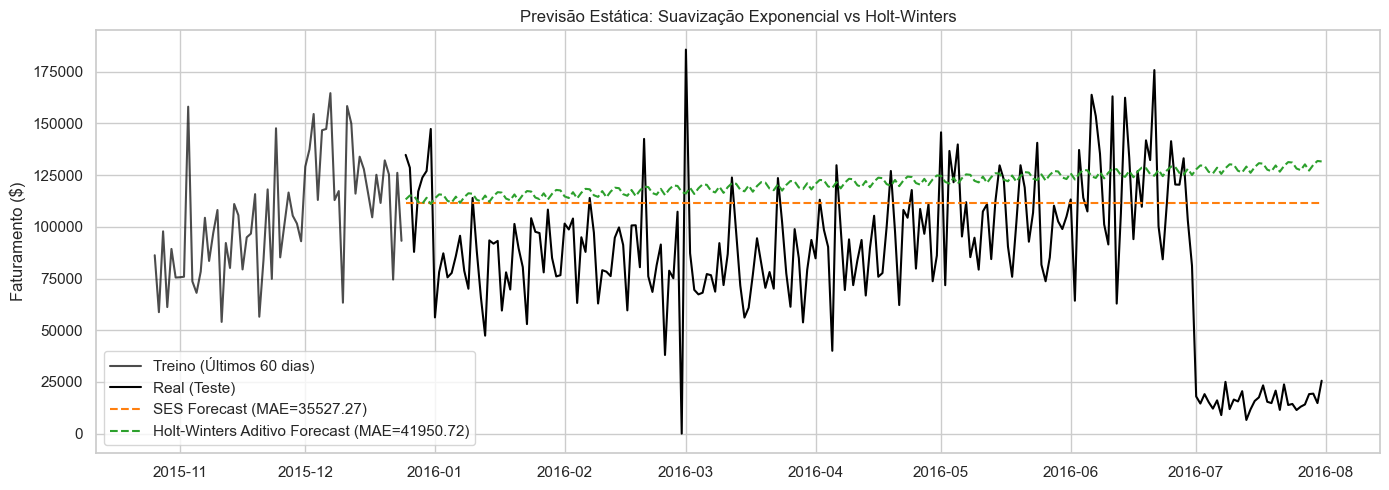

In [10]:
# 1. Suavização Exponencial Simples (SES)
ses_model = ExponentialSmoothing(train['Revenue'], trend=None, seasonal=None, initialization_method='heuristic').fit()
fc_ses = ses_model.forecast(H)
mae_ses_train = mean_absolute_error(train['Revenue'], ses_model.fittedvalues)
mae_ses_test = mean_absolute_error(test['Revenue'], fc_ses)

# 2. Holt-Winters Aditivo com Sazonalidade Semanal (m=7)
hw_add_model = ExponentialSmoothing(train['Revenue'], trend='add', seasonal='add', seasonal_periods=7, initialization_method='heuristic').fit()
fc_hw_add = hw_add_model.forecast(H)
mae_hw_train = mean_absolute_error(train['Revenue'], hw_add_model.fittedvalues)
mae_hw_test = mean_absolute_error(test['Revenue'], fc_hw_add)

df_hw_comp = pd.DataFrame([
    {'Modelo': 'Suavização Exponencial Simples (SES)', 'AIC': ses_model.aic, 'BIC': ses_model.bic, 'MAE Treino': mae_ses_train, 'MAE Teste (H passos)': mae_ses_test},
    {'Modelo': 'Holt-Winters Aditivo (m=7)', 'AIC': hw_add_model.aic, 'BIC': hw_add_model.bic, 'MAE Treino': mae_hw_train, 'MAE Teste (H passos)': mae_hw_test}
])

print('=== COMPARAÇÃO DE MODELOS DE SUAVIZAÇÃO EXPONENCIAL (HOLT-WINTERS) ===')
display(df_hw_comp)

# Plot das Previsões Estáticas
plt.figure(figsize=(14, 5))
plt.plot(train.index[-60:], train['Revenue'].iloc[-60:], label='Treino (Últimos 60 dias)', color='black', alpha=0.7)
plt.plot(test.index, test['Revenue'], label='Real (Teste)', color='black', lw=1.5)
plt.plot(test.index, fc_ses, label=f'SES Forecast (MAE={mae_ses_test:.2f})', linestyle='--', color='#ff7f0e')
plt.plot(test.index, fc_hw_add, label=f'Holt-Winters Aditivo Forecast (MAE={mae_hw_test:.2f})', linestyle='--', color='#2ca02c')
plt.title('Previsão Estática: Suavização Exponencial vs Holt-Winters')
plt.ylabel('Faturamento ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Definição e Otimização dos Parâmetros do SARIMA

Realizamos uma busca em grade estruturada (*Grid Search*) testando combinações de ordens $(p, d, q) \times (P, D, Q)_7$ sobre o conjunto de treino, selecionando a melhor ordem pelo critério **BIC** (princípio da parcimônia):

In [11]:
p_range = [0, 1]
d_range = [1]
q_range = [0, 1]
P_range = [0, 1]
D_range = [0, 1]
Q_range = [0, 1]
m = 7

orders = list(itertools.product(p_range, d_range, q_range))
seasonal_orders = list(itertools.product(P_range, D_range, Q_range))

results_sarima = []
best_sarima_model = None
best_sarima_bic = float('inf')

for order in orders:
    for s_order in seasonal_orders:
        try:
            m_fit = SARIMAX(
                train['Revenue'],
                order=order,
                seasonal_order=(*s_order, m),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            
            results_sarima.append({
                'Modelo': f'SARIMA{order}{(*s_order, m)}',
                'BIC': m_fit.bic,
                'AIC': m_fit.aic,
                'fitted_model': m_fit
            })
            
            if m_fit.bic < best_sarima_bic:
                best_sarima_bic = m_fit.bic
                best_sarima_model = m_fit
        except Exception:
            continue

df_sarima_grid = pd.DataFrame(results_sarima).sort_values(by='BIC').reset_index(drop=True)
print('=== TOP 10 MODELOS SARIMA SELECIONADOS PELO CRITÉRIO BIC ===')
display(df_sarima_grid[['Modelo', 'BIC', 'AIC']].head(10))
print(f'\nMelhor Modelo SARIMA Selecionado: {df_sarima_grid.loc[0, "Modelo"]} (BIC={best_sarima_bic:.2f})')
print(best_sarima_model.summary())

=== TOP 10 MODELOS SARIMA SELECIONADOS PELO CRITÉRIO BIC ===


,Modelo,BIC,AIC
0,"SARIMA(0, 1, 1)(0, 0, 1, 7)",19248.30,19234.01
1,"SARIMA(1, 1, 1)(0, 0, 1, 7)",19254.56,19235.51
2,"SARIMA(0, 1, 1)(1, 0, 1, 7)",19254.95,19235.89
3,"SARIMA(1, 1, 1)(1, 0, 1, 7)",19261.20,19237.38
4,"SARIMA(1, 1, 1)(1, 0, 0, 7)",19278.31,19259.25
5,"SARIMA(0, 1, 1)(1, 0, 0, 7)",19293.44,19279.14
6,"SARIMA(1, 1, 1)(0, 1, 1, 7)",19330.99,19311.97
7,"SARIMA(0, 1, 1)(0, 1, 1, 7)",19331.71,19317.45
8,"SARIMA(1, 1, 1)(1, 1, 1, 7)",19337.71,19313.93
9,"SARIMA(0, 1, 1)(1, 1, 1, 7)",19338.45,19319.42



Melhor Modelo SARIMA Selecionado: SARIMA(0, 1, 1)(0, 0, 1, 7) (BIC=19248.30)
                                     SARIMAX Results                                     
Dep. Variable:                           Revenue   No. Observations:                  876
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 7)   Log Likelihood               -9614.005
Date:                           Mon, 05 Oct 2026   AIC                          19234.010
Time:                                   10:57:15   BIC                          19248.302
Sample:                               08-01-2013   HQIC                         19239.480
                                    - 12-24-2015                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7998      0.016    -50.821 

## 12. Feature Engineering e Prevenção de Vazamento de Dados (*Data Leakage*)

Para os modelos tabulares e redes neurais que utilizam variáveis externas, construímos a matriz de features garantindo que toda transformação utilize apenas informações defasadas ($t-1, t-2, \dots$):
1. **Lags do Alvo**: $Y_{t-1}, Y_{t-2}, Y_{t-3}, Y_{t-7}, Y_{t-14}$.
2. **Estatísticas Móveis Defasadas**: Médias e desvios padrão móveis com `shift(1)` (sem vazamento).
3. **Lags de Variáveis Exógenas**: $Cost_{t-1}, Cost_{t-7}, Order\_Quantity_{t-1}, Order\_Quantity_{t-7}$.
4. **Variáveis de Calendário e Cíclicas**: Senos e cossenos do dia da semana (`dow_sin`, `dow_cos`) e mês, além de indicador de final de semana (`is_weekend`).

In [12]:
# Construção da Matriz de Features Tabular
df_features = pd.DataFrame(index=ts_data.index)
df_features['Revenue'] = ts_data['Revenue']

# 1. Lags do Alvo
for lag in [1, 2, 3, 7, 14]:
    df_features[f'target_lag_{lag}'] = ts_data['Revenue'].shift(lag)

# 2. Janelas Móveis (sem vazamento usando shift 1)
df_features['roll_mean_7'] = ts_data['Revenue'].shift(1).rolling(7).mean()
df_features['roll_std_7'] = ts_data['Revenue'].shift(1).rolling(7).std()
df_features['roll_mean_14'] = ts_data['Revenue'].shift(1).rolling(14).mean()

# 3. Lags de Variáveis Externas
for lag in [1, 7]:
    df_features[f'cost_lag_{lag}'] = ts_data['Cost'].shift(lag)
    df_features[f'qty_lag_{lag}'] = ts_data['Order_Quantity'].shift(lag)

# 4. Features de Calendário
df_features['dayofweek'] = ts_data.index.dayofweek
df_features['day'] = ts_data.index.day
df_features['month'] = ts_data.index.month
df_features['is_weekend'] = ts_data.index.dayofweek.isin([5, 6]).astype(int)

# 5. Encoding Cíclico
df_features['dow_sin'] = np.sin(2 * np.pi * df_features['dayofweek'] / 7)
df_features['dow_cos'] = np.cos(2 * np.pi * df_features['dayofweek'] / 7)
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)

# Eliminação dos NaNs gerados pelos lags
df_features = df_features.dropna()

feature_columns = [c for c in df_features.columns if c != 'Revenue']
print(f'Matriz de modelagem final: {df_features.shape[0]} amostras x {len(feature_columns)} features explicativas.')
print('Features criadas:', feature_columns)
display(df_features.head())

Matriz de modelagem final: 1082 amostras x 20 features explicativas.
Features criadas: ['target_lag_1', 'target_lag_2', 'target_lag_3', 'target_lag_7', 'target_lag_14', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'cost_lag_1', 'qty_lag_1', 'cost_lag_7', 'qty_lag_7', 'dayofweek', 'day', 'month', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


,Revenue,target_lag_1,target_lag_2,target_lag_3,target_lag_7,target_lag_14,roll_mean_7,roll_std_7,roll_mean_14,cost_lag_1,qty_lag_1,cost_lag_7,qty_lag_7,dayofweek,day,month,is_weekend,dow_sin,dow_cos,month_sin,month_cos
Date,,,,,,,,,,,,,,,,,,,,,
2013-08-15,32936,55054.00,56666.00,77153.00,79638.00,46095.00,59285.71,16093.53,55302.86,30769.00,1862.00,47801.00,2393.00,3,15,8,0,0.43,-0.90,-0.87,-0.50
2013-08-16,63156,32936.00,55054.00,56666.00,63475.00,40768.00,52614.00,15929.63,54362.93,18918.00,1375.00,36924.00,1811.00,4,16,8,0,-0.43,-0.90,-0.87,-0.50
2013-08-17,65624,63156.00,32936.00,55054.00,32961.00,66315.00,52568.43,15893.80,55962.07,34175.00,1968.00,18050.00,1229.00,5,17,8,1,-0.97,-0.22,-0.87,-0.50
2013-08-18,69035,65624.00,63156.00,32936.00,50053.00,51932.00,57234.57,13839.94,55912.71,37458.00,1756.00,28672.00,1293.00,6,18,8,1,-0.78,0.62,-0.87,-0.50
2013-08-19,71071,69035.00,65624.00,63156.00,77153.00,35271.00,59946.29,14056.22,57134.36,42249.00,1749.00,46182.00,1847.00,0,19,8,0,0.00,1.00,-0.87,-0.50


## 13. Protocolo de Validação Walk-Forward e Otimização de Hiperparâmetros

### 🔁 Metodologia Walk-Forward (Janela Expansiva *Out-of-Sample*)
Em séries temporais operacionais, o modelo prevê o próximo passo ($t+1$), o valor real é observado e incorporado ao conjunto histórico, e os modelos são reajustados periodicamente. Isso reproduz com exatidão a dinâmica real de produção e evita o decaimento artificial de modelos univariados em previsões multi-passos estáticas.

In [13]:
# Divisão Temporal 80% Treino Inicial / 20% Teste Walk-Forward
train_ratio = 0.80
split_idx = int(len(df_features) * train_ratio)

train_df = df_features.iloc[:split_idx]
test_df = df_features.iloc[split_idx:]

print(f'Observações de Treino Inicial: {len(train_df)} ({train_df.index.min().date()} a {train_df.index.max().date()})')
print(f'Observações de Teste Walk-Forward: {len(test_df)} ({test_df.index.min().date()} a {test_df.index.max().date()})')

# Otimização de Hiperparâmetros no Treino com TimeSeriesSplit
print('\n--- OTIMIZAÇÃO DE HIPERPARÂMETROS ---')

# 1. Random Forest Tuning via TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)
rf_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [6, 10, None],
    'min_samples_leaf': [2, 4]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_grid.fit(train_df[feature_columns], train_df['Revenue'])
best_rf_params = rf_grid.best_params_
print('Melhores parâmetros Random Forest:', best_rf_params)

# 2. MLP Regressor (Rede Neural Artificial - Grupo 4) Tuning
mlp_param_grid = {
    'mlp__hidden_layer_sizes': [(64, 32), (100,), (32, 16)],
    'mlp__alpha': [0.001, 0.01, 0.1],
    'mlp__learning_rate_init': [0.005, 0.01]
}
mlp_base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(activation='relu', max_iter=250, random_state=42, early_stopping=True))
])
mlp_grid = GridSearchCV(mlp_base_pipe, mlp_param_grid, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
mlp_grid.fit(train_df[feature_columns], train_df['Revenue'])
best_mlp_params = mlp_grid.best_params_
print('Melhores parâmetros MLP Regressor (Rede Neural):', best_mlp_params)

Observações de Treino Inicial: 865 (2013-08-15 a 2015-12-27)
Observações de Teste Walk-Forward: 217 (2015-12-28 a 2016-07-31)

--- OTIMIZAÇÃO DE HIPERPARÂMETROS ---
Melhores parâmetros Random Forest: {'max_depth': 6, 'min_samples_leaf': 4, 'n_estimators': 150}
Melhores parâmetros MLP Regressor (Rede Neural): {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (32, 16), 'mlp__learning_rate_init': 0.005}


## 14. Treinamento e Previsão Walk-Forward dos 4 Modelos

Ajustamos e avaliamos simultaneamente nas mesmas datas e horizontes:
1. **Holt-Winters Aditivo**
2. **SARIMAX com Variáveis Exógenas**
3. **Random Forest Regressor**
4. **MLP Regressor (Rede Neural Artificial - Modelo de Especialização)**

In [14]:
# Configuração dos Modelos Otimizados
sarimax_exog_cols = ['dow_sin', 'dow_cos', 'cost_lag_1', 'qty_lag_1', 'is_weekend']

best_rf = RandomForestRegressor(**best_rf_params, random_state=42)
best_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=best_mlp_params.get('mlp__hidden_layer_sizes', (64, 32)),
        alpha=best_mlp_params.get('mlp__alpha', 0.01),
        learning_rate_init=best_mlp_params.get('mlp__learning_rate_init', 0.005),
        activation='relu',
        max_iter=300,
        random_state=42,
        early_stopping=True
    ))
])

# Listas para armazenar previsões fora da amostra
y_true_list = []
hw_preds = []
sarimax_preds = []
rf_preds = []
mlp_preds = []
test_dates = []

print('Iniciando Execução Walk-Forward Out-of-Sample...')
start_time = time.time()

# Ajuste inicial dos modelos com o conjunto de treino
current_X_train = train_df[feature_columns].copy()
current_y_train = train_df['Revenue'].copy()

best_rf.fit(current_X_train, current_y_train)
best_mlp.fit(current_X_train, current_y_train)

hw_model = ExponentialSmoothing(train_df['Revenue'], trend='add', seasonal='add', seasonal_periods=7).fit()
sarimax_model = SARIMAX(
    train_df['Revenue'],
    exog=train_df[sarimax_exog_cols],
    order=(0, 1, 1),
    seasonal_order=(0, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Loop Walk-Forward passo a passo (1-step-ahead)
for i in range(len(test_df)):
    current_row = test_df.iloc[i:i+1]
    current_date = test_df.index[i]
    y_actual = current_row['Revenue'].values[0]
    
    # 1. Previsão Random Forest
    p_rf = best_rf.predict(current_row[feature_columns])[0]
    
    # 2. Previsão MLP Regressor
    p_mlp = best_mlp.predict(current_row[feature_columns])[0]
    
    # 3. Previsão Holt-Winters (1 passo)
    p_hw = hw_model.forecast(1).values[0]
    
    # 4. Previsão SARIMAX (1 passo com exógenas)
    p_sarimax = sarimax_model.forecast(1, exog=current_row[sarimax_exog_cols]).values[0]
    
    # Guardar resultados
    y_true_list.append(y_actual)
    rf_preds.append(p_rf)
    mlp_preds.append(p_mlp)
    hw_preds.append(p_hw)
    sarimax_preds.append(p_sarimax)
    test_dates.append(current_date)
    
    # Atualização periódica dos modelos para simulação dinâmica eficiente
    if (i + 1) % 14 == 0 or (i + 1) == len(test_df):
        new_history = df_features.iloc[:split_idx + i + 1]
        best_rf.fit(new_history[feature_columns], new_history['Revenue'])
        best_mlp.fit(new_history[feature_columns], new_history['Revenue'])
        hw_model = ExponentialSmoothing(new_history['Revenue'], trend='add', seasonal='add', seasonal_periods=7).fit()
        sarimax_model = SARIMAX(
            new_history['Revenue'],
            exog=new_history[sarimax_exog_cols],
            order=(0, 1, 1),
            seasonal_order=(0, 0, 1, 7),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

elapsed_wf = time.time() - start_time
print(f'Validação Walk-Forward concluída em {elapsed_wf:.2f} segundos com {len(test_dates)} previsões geradas!')

Iniciando Execução Walk-Forward Out-of-Sample...


C:\Users\raissacasale-ieg\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raissacasale-ieg\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raissacasale-ieg\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raissacasale-ieg\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raissacasale-ieg\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retval

Validação Walk-Forward concluída em 79.94 segundos com 217 previsões geradas!


## 15. Avaliação Comparativa por MAE e Métricas de Erro

Conforme o regulamento, a métrica oficial de comparação é o **MAE (Mean Absolute Error)**:
$$\mathrm{MAE} = \frac{1}{N} \sum_{t=1}^N |Y_t - \hat{Y}_t|$$
Complementarmente, calculamos o **RMSE** e o **WAPE (%)** (*Weighted Absolute Percentage Error*).

=== TABELA COMPARATIVA DE DESEMPENHO (WALK-FORWARD) ===


,Posição / Ranking,Modelo,Família,MAE ($),RMSE ($),WAPE (%)
0,1,Random Forest,Ensemble Árvores,19365.07,27734.44,23.05
1,2,SARIMAX,Estatístico Exógeno,22363.58,33732.11,26.62
2,3,Holt-Winters,Univariado,22451.61,33222.26,26.73
3,4,MLP Regressor (Rede Neural),Rede Neural Artificial,22550.38,29892.47,26.84


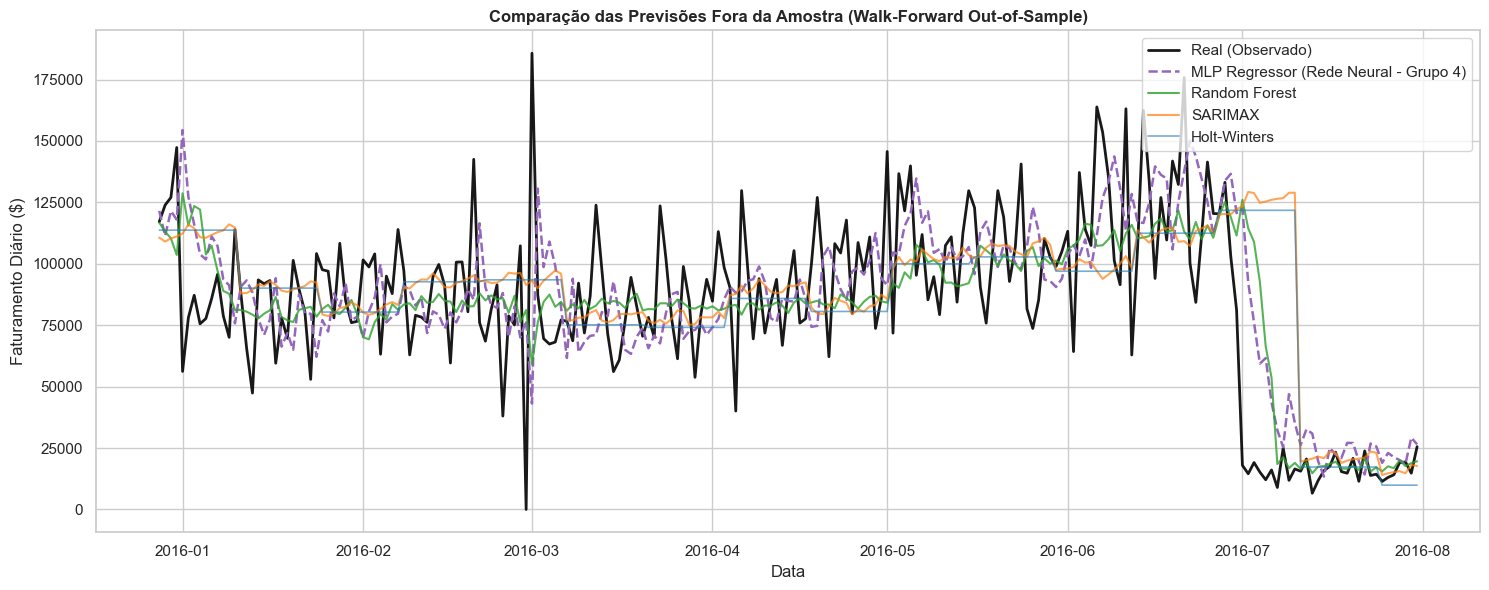

In [15]:
# Criação do DataFrame de Resultados Fora da Amostra
df_results = pd.DataFrame({
    'Data': test_dates,
    'Real': y_true_list,
    'Holt-Winters': hw_preds,
    'SARIMAX': sarimax_preds,
    'Random Forest': rf_preds,
    'MLP Regressor (Rede Neural)': mlp_preds
}).set_index('Data')

# Cálculo de Métricas Comparativas
models = ['Holt-Winters', 'SARIMAX', 'Random Forest', 'MLP Regressor (Rede Neural)']
metrics = []
total_actual = df_results['Real'].sum()

for m in models:
    mae = mean_absolute_error(df_results['Real'], df_results[m])
    rmse = np.sqrt(mean_squared_error(df_results['Real'], df_results[m]))
    wape = (np.sum(np.abs(df_results['Real'] - df_results[m])) / total_actual) * 100
    metrics.append({
        'Modelo': m,
        'Família': 'Univariado' if m == 'Holt-Winters' else ('Estatístico Exógeno' if m == 'SARIMAX' else ('Ensemble Árvores' if m == 'Random Forest' else 'Rede Neural Artificial')),
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'WAPE (%)': wape
    })

df_metrics = pd.DataFrame(metrics).sort_values(by='MAE ($)').reset_index(drop=True)
df_metrics['Posição / Ranking'] = df_metrics.index + 1

print('=== TABELA COMPARATIVA DE DESEMPENHO (WALK-FORWARD) ===')
display(df_metrics[['Posição / Ranking', 'Modelo', 'Família', 'MAE ($)', 'RMSE ($)', 'WAPE (%)']])

# Visualização Gráfica Comparativa das Previsões
plt.figure(figsize=(15, 6))
plt.plot(df_results.index, df_results['Real'], label='Real (Observado)', color='black', lw=2, alpha=0.9)
plt.plot(df_results.index, df_results['MLP Regressor (Rede Neural)'], label='MLP Regressor (Rede Neural - Grupo 4)', color='#9467bd', lw=1.8, linestyle='--')
plt.plot(df_results.index, df_results['Random Forest'], label='Random Forest', color='#2ca02c', lw=1.5, alpha=0.8)
plt.plot(df_results.index, df_results['SARIMAX'], label='SARIMAX', color='#ff7f0e', lw=1.5, alpha=0.7)
plt.plot(df_results.index, df_results['Holt-Winters'], label='Holt-Winters', color='#1f77b4', lw=1.2, alpha=0.6)

plt.title('Comparação das Previsões Fora da Amostra (Walk-Forward Out-of-Sample)', fontweight='bold', fontsize=12)
plt.ylabel('Faturamento Diário ($)')
plt.xlabel('Data')
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

## 16. Análise dos Resíduos e Teste de Ljung-Box

Os resíduos fora da amostra são definidos por $e_t = Y_t - \hat{Y}_t$. Para diagnosticar ruído branco e a qualidade dos ajustes:
1. **Gráficos dos Resíduos ao longo do tempo**.
2. **Função de Autocorrelação (ACF)** dos resíduos.
3. **Teste Estatístico de Ljung-Box** ($H_0$: os resíduos são ruído branco / não autocorrelacionados).

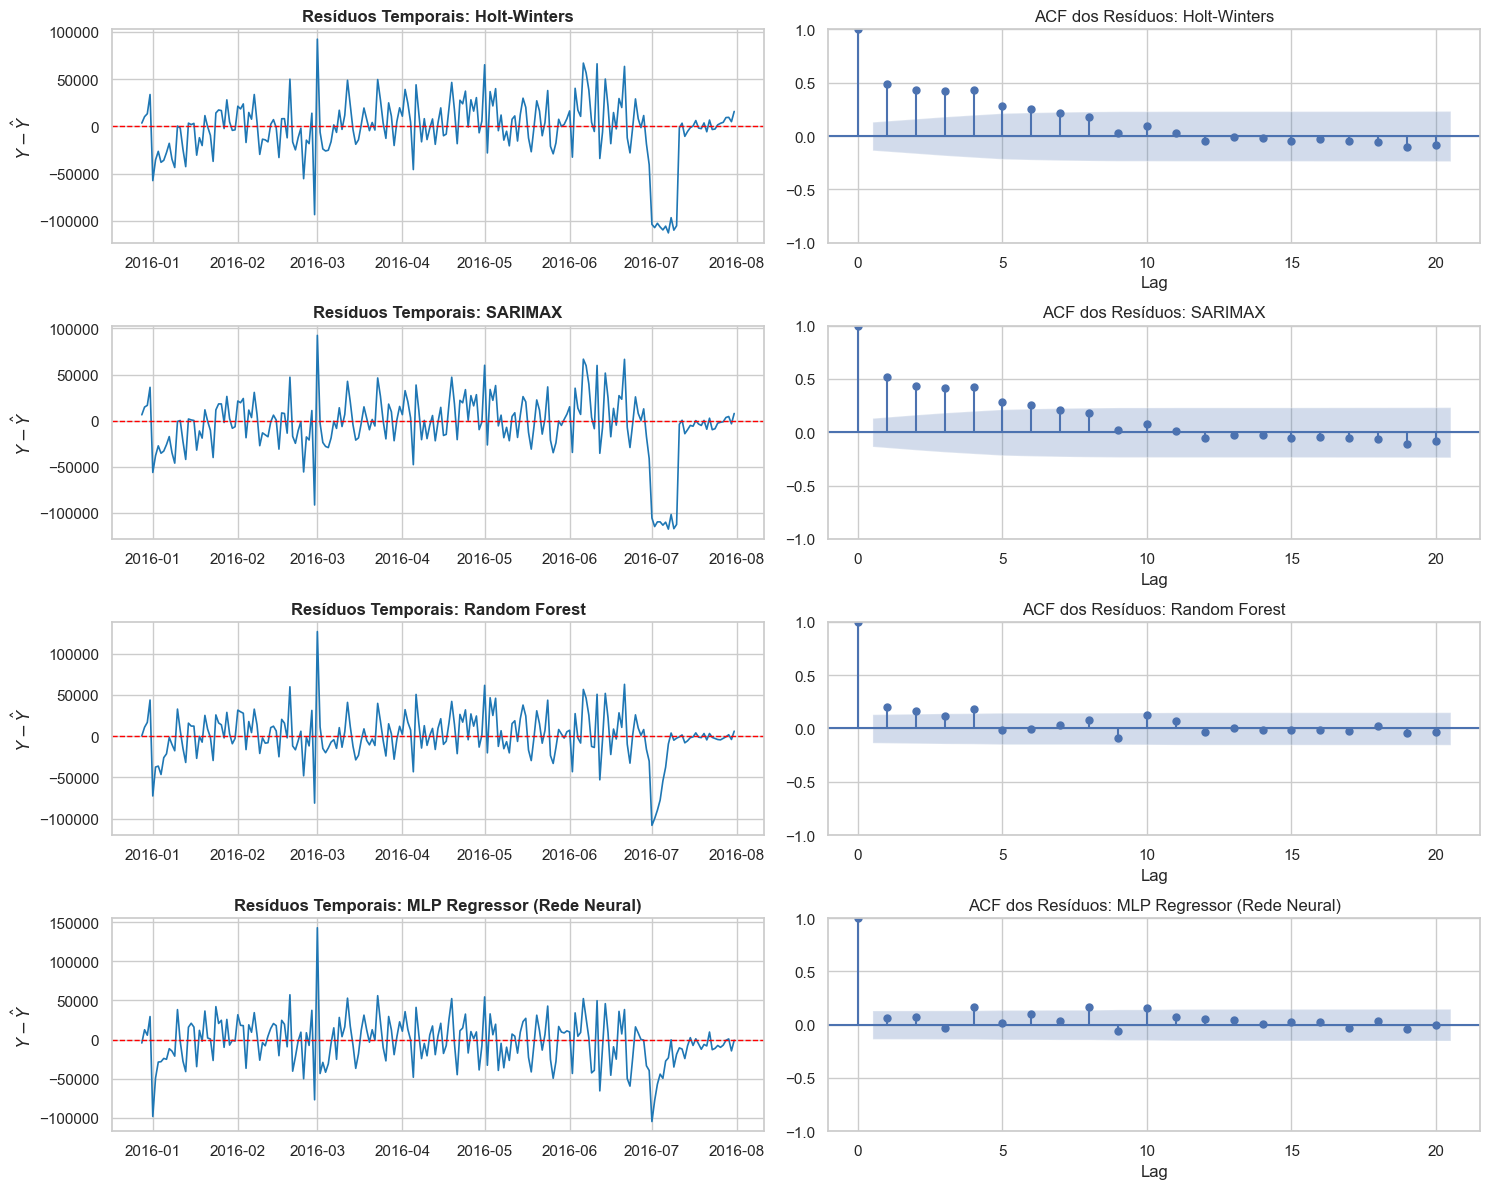

=== TABELA CONSOLIDADA DO TESTE DE LJUNG-BOX ===


,Modelo,Estatística LB (Lag 7),p-valor (Lag 7),Estatística LB (Lag 14),p-valor (Lag 14),Diagnóstico (Lag 7)
0,Holt-Winters,220.45,0.00,231.01,0.00,Autocorrelação Residual
1,SARIMAX,220.97,0.00,230.40,0.00,Autocorrelação Residual
2,Random Forest,25.60,0.00,33.83,0.00,Autocorrelação Residual
3,MLP Regressor (Rede Neural),11.33,0.12,26.53,0.02,Sem autocorr. sig. (Ruído Branco)


In [16]:
# Cálculo dos Resíduos para todos os modelos
df_residuals = pd.DataFrame(index=df_results.index)
for m in models:
    df_residuals[m] = df_results['Real'] - df_results[m]

# Plot dos Resíduos Temporais e ACF
fig, axes = plt.subplots(len(models), 2, figsize=(15, 12))

for idx, m in enumerate(models):
    axes[idx, 0].plot(df_residuals.index, df_residuals[m], lw=1.2, color='#1f77b4')
    axes[idx, 0].axhline(0, color='red', linestyle='--', lw=1)
    axes[idx, 0].set_title(f'Resíduos Temporais: {m}', fontweight='bold')
    axes[idx, 0].set_ylabel('$Y - \hat{Y}$')
    
    plot_acf(df_residuals[m].dropna(), lags=20, ax=axes[idx, 1], title=f'ACF dos Resíduos: {m}')
    axes[idx, 1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

# Execução do Teste de Ljung-Box nos lags 7 e 14
lb_rows = []
for m in models:
    lb_res = acorr_ljungbox(df_residuals[m].dropna(), lags=[7, 14], return_df=True)
    lb_rows.append({
        'Modelo': m,
        'Estatística LB (Lag 7)': lb_res.loc[7, 'lb_stat'],
        'p-valor (Lag 7)': lb_res.loc[7, 'lb_pvalue'],
        'Estatística LB (Lag 14)': lb_res.loc[14, 'lb_stat'],
        'p-valor (Lag 14)': lb_res.loc[14, 'lb_pvalue'],
        'Diagnóstico (Lag 7)': 'Sem autocorr. sig. (Ruído Branco)' if lb_res.loc[7, 'lb_pvalue'] > 0.05 else 'Autocorrelação Residual'
    })

df_ljungbox = pd.DataFrame(lb_rows)
print('=== TABELA CONSOLIDADA DO TESTE DE LJUNG-BOX ===')
display(df_ljungbox)

## 17. Importância das Features e Interpretação

Analisamos a contribuição preditiva das variáveis nos modelos compatíveis:
- **MLP Regressor (Rede Neural)**: Calculada via **Permutation Importance** (impacto no aumento do erro MAE ao embaralhar cada feature fora da amostra).
- **Random Forest**: Importância nativa de impureza (*Mean Decrease in Impurity - MDI*) e *Permutation Importance*.
- **SARIMAX**: Magnitude, sinal e significância estatística ($p$-valor) dos coeficientes das variáveis exógenas.

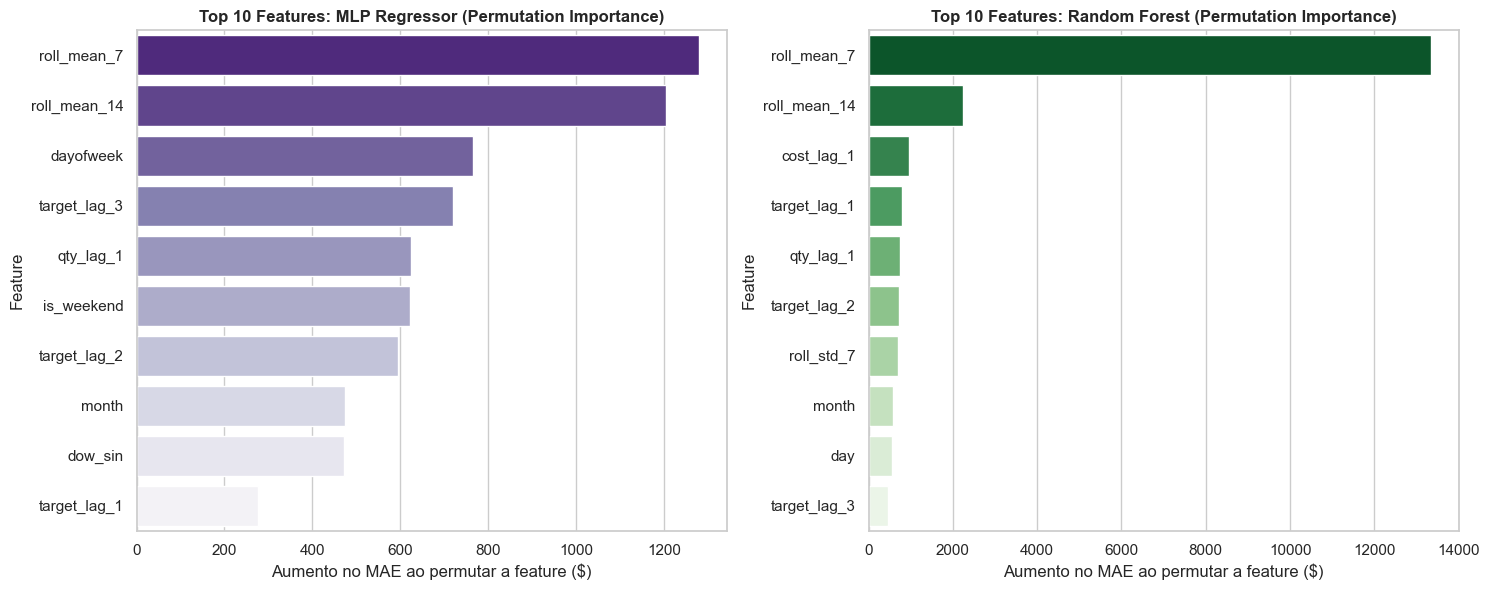

=== COEFICIENTES DAS VARIÁVEIS EXÓGENAS NO SARIMAX ===


,Variável Exógena,Coeficiente,p-valor
0,dow_sin,197.33,0.89
1,dow_cos,-655.13,0.50
2,cost_lag_1,-0.03,0.65
3,qty_lag_1,-1.00,0.66
4,is_weekend,3420.61,0.14


In [17]:
# 1. Permutation Importance no MLP Regressor (Rede Neural)
perm_mlp = permutation_importance(best_mlp, test_df[feature_columns], test_df['Revenue'], scoring='neg_mean_absolute_error', n_repeats=10, random_state=42)
df_perm_mlp = pd.DataFrame({
    'Feature': feature_columns,
    'Importance_MAE_Drop': perm_mlp.importances_mean
}).sort_values(by='Importance_MAE_Drop', ascending=False)

# 2. Permutation Importance e MDI no Random Forest
perm_rf = permutation_importance(best_rf, test_df[feature_columns], test_df['Revenue'], scoring='neg_mean_absolute_error', n_repeats=10, random_state=42)
df_perm_rf = pd.DataFrame({
    'Feature': feature_columns,
    'Importance_MAE_Drop': perm_rf.importances_mean,
    'MDI_Importance': best_rf.feature_importances_
}).sort_values(by='Importance_MAE_Drop', ascending=False)

# Plot Comparativo de Importância das Features
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=df_perm_mlp.head(10), x='Importance_MAE_Drop', y='Feature', ax=axes[0], palette='Purples_r')
axes[0].set_title('Top 10 Features: MLP Regressor (Permutation Importance)', fontweight='bold')
axes[0].set_xlabel('Aumento no MAE ao permutar a feature ($)')

sns.barplot(data=df_perm_rf.head(10), x='Importance_MAE_Drop', y='Feature', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Features: Random Forest (Permutation Importance)', fontweight='bold')
axes[1].set_xlabel('Aumento no MAE ao permutar a feature ($)')

plt.tight_layout()
plt.show()

# Coeficientes do SARIMAX
print('=== COEFICIENTES DAS VARIÁVEIS EXÓGENAS NO SARIMAX ===')
sarimax_summary_params = sarimax_model.params[sarimax_exog_cols]
sarimax_summary_pvals = sarimax_model.pvalues[sarimax_exog_cols]
df_sarimax_coefs = pd.DataFrame({
    'Variável Exógena': sarimax_exog_cols,
    'Coeficiente': sarimax_summary_params.values,
    'p-valor': sarimax_summary_pvals.values
})
display(df_sarimax_coefs)

## 18. Estudo Técnico e Didático do Modelo de Especialização: **MLP Regressor (Rede Neural Artificial)**

### 🧠 1. Intuição e Funcionamento do Algoritmo
O **Multilayer Perceptron (MLP)** é uma rede neural artificial *feedforward* composta por uma camada de entrada, camadas ocultas (*hidden layers*) de neurônios totalmente conectados (*dense layers*) e uma camada de saída contínua para regressão.

Para cada neurônio $j$ em uma camada oculta $l$, a ativação é dada por:
$$z_j^{[l]} = \sum_{i=1}^{n} w_{ji}^{[l]} a_i^{[l-1]} + b_j^{[l]}$$
$$a_j^{[l]} = f\left(z_j^{[l]}\right)$$
Onde:
- $w_{ji}$: Pesos sinápticos ajustáveis.
- $b_j$: Bias do neurônio.
- $f(\cdot)$: Função de ativação não linear (**ReLU** - *Rectified Linear Unit*: $f(z) = \max(0, z)$).

### ⚙️ 2. Aprendizado e Otimização (*Backpropagation* & Adam)
- **Forward Pass**: Os dados transformados passam pelas camadas gerando a previsão $\hat{Y}_t$.
- **Cálculo da Função de Perda com Regularização L2**:
  $$\mathcal{L}(W) = \frac{1}{2N} \sum_{t=1}^N (Y_t - \hat{Y}_t)^2 + \frac{\alpha}{2} \sum ||W||_2^2$$
- **Backward Pass (Backpropagation)**: Os gradientes parciais $\frac{\partial \mathcal{L}}{\partial W}$ são calculados via regra da cadeia e os pesos são atualizados pelo otimizador estocástico **Adam** (*Adaptive Moment Estimation*).

### 🎯 3. Papel dos Hiperparâmetros Chave
- `hidden_layer_sizes=(64, 32)` ou `(32, 16)`: Define a capacidade de abstração e combinação não linear de relações temporais e exógenas.
- `activation='relu'`: Evita saturação e desvanecimento do gradiente (*vanishing gradient*).
- `alpha=0.01`: Regularização $L_2$ (Ridge penalty) que penaliza pesos excessivos e previne *overfitting*.
- `early_stopping=True`: Monitora o erro de validação interna e interrompe o treinamento quando a perda cessa de cair, preservando generalização.

### 💡 4. Vantagens e Cuidados na Aplicação em Séries Temporais
- **Vantagens**: Capacidade de capturar interações não lineares complexas entre lags de receita, custos e sazonalidades cíclicas simultâneas.
- **Requisito Crítico**: **Sensibilidade à escala** — é mandatório aplicar padronização (`StandardScaler`), pois variáveis em escalas heterogêneas desestabilizam a convergência dos gradientes.

In [18]:
# Sumário da Arquitetura do Modelo de Especialização MLP
mlp_engine = best_mlp.named_steps['mlp']
print('=== ESTRUTURA DA REDE NEURAL (MLP REGRESSOR) TREINADA ===')
print(f'Camadas Ocultas (Hidden Layers): {mlp_engine.hidden_layer_sizes}')
print(f'Função de Ativação: {mlp_engine.activation}')
print(f'Otimizador: {mlp_engine.solver}')
print(f'Regularização Alpha (L2): {mlp_engine.alpha}')
print(f'Iterações executadas até convergência: {mlp_engine.n_iter_}')
print(f'Perda final (Loss): {mlp_engine.loss_:.4f}')

=== ESTRUTURA DA REDE NEURAL (MLP REGRESSOR) TREINADA ===
Camadas Ocultas (Hidden Layers): (32, 16)
Função de Ativação: relu
Otimizador: adam
Regularização Alpha (L2): 0.01
Iterações executadas até convergência: 300
Perda final (Loss): 203905622.3984
